# 02 -- Baselines: от популярности до BM25

Все методы используют один полный локальный каталог и один split из `01`.
Медиана не является baseline для retrieval: ее аналог здесь -- один глобальный список популярных items.
Naive Bayes предсказывает microcategory, затем выбирает популярные объявления внутри нее.

Показываю только development. Test-кандидаты вычисляются без чтения их разметки; оценка в `06`.
Префикс `bl_`. Индексы по текстам каталога -- unsupervised, история и NB учатся только на base.

In [1]:
from pathlib import Path
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

bl_root = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
get_ipython().run_line_magic('run', str(bl_root / 'notebooks/common.ipynb'))
bl_out = bl_root / 'outputs'
bl_seed = 143


In [2]:
import joblib
import gc

bl_items = pd.read_parquet(bl_out / 'cache/items.parquet')
bl_queries = pd.read_parquet(bl_out / 'cache/eval_queries.parquet')
bl_base = pd.read_parquet(bl_out / 'cache/base_pairs.parquet')
bl_truth_all = json.loads((bl_out / 'cache/truth.json').read_text())
bl_dev = bl_queries[bl_queries.split.eq('dev')]
bl_truth = {q: bl_truth_all[q] for q in bl_dev.query_id}
bl_index = LexicalIndex().fit(bl_items)
joblib.dump(bl_index, bl_out / 'cache/lexical_index.joblib', compress=0)
bl_history = HistoryIndex().fit(bl_base, bl_items)
joblib.dump(bl_history, bl_out / 'cache/history_index.joblib', compress=0)
print('Корпус:', len(bl_items), 'base:', len(bl_base), 'dev:', len(bl_dev))


Корпус: 515895 base: 322191 dev: 2000


## Поиск и сохранение кандидатов

Для каждого lexical метода сохраняю global и same-location top-120. Локальный канал дополняет глобальный,
а не отсекает его. Одинаковые скоры упорядочены по стабильному item-порядку.
Словарь ограничен по частоте; отсутствие токенов дает пустой ответ, а не случайные нулевые совпадения.
В `03` это компенсирует объединение источников.

In [3]:
bl_times = []
for bl_method in ['overlap', 'word', 'char', 'bm25', 'bm25_title']:
    bl_start = time.monotonic()
    bl_candidates = bl_index.search(bl_queries, bl_items, k=120, methods=[bl_method])
    bl_candidates.to_parquet(
        bl_out / f'cache/candidates_{bl_method}.parquet', index=False
    )
    bl_times.append(
        {
            'method': bl_method,
            'queries': len(bl_queries),
            'seconds': time.monotonic() - bl_start,
            'candidate_rows': len(bl_candidates),
        }
    )
    del bl_candidates
    gc.collect()
bl_start = time.monotonic()
bl_history_parts = []
for bl_startrow in range(0, len(bl_queries), 700):
    bl_part = bl_history.search(bl_queries.iloc[bl_startrow : bl_startrow + 700], k=120)
    bl_history_parts.append(bl_part)
bl_candidates = pd.concat(bl_history_parts, ignore_index=True)
bl_candidates.to_parquet(bl_out / 'cache/candidates_history.parquet', index=False)
bl_times.append(
    {
        'method': 'history+NB+pop',
        'queries': len(bl_queries),
        'seconds': time.monotonic() - bl_start,
        'candidate_rows': len(bl_candidates),
    }
)


overlap: 8400 queries, 6.8s


word: 8400 queries, 174.2s


char: 8400 queries, 66.7s


bm25: 8400 queries, 154.7s


bm25_title: 8400 queries, 6.5s


In [4]:
pd.DataFrame(bl_times).to_csv(bl_out / 'validation/retrieval_timings.csv', index=False)
del bl_candidates, bl_history_parts
gc.collect()


456

In [5]:
bl_scores = []
bl_per_query = []
for bl_file in sorted((bl_out / 'cache').glob('candidates_*.parquet')):
    if bl_file.stem in ['candidates_dense', 'candidates_adapted']:
        continue
    bl_c = pd.read_parquet(bl_file)
    bl_c = bl_c[bl_c.query_id.isin(bl_dev.query_id)]
    for bl_source, bl_group in bl_c.groupby('source', observed=True):
        bl_pred = predictions_from_frame(
            bl_group.sort_values(['query_id', 'rank']), bl_items, k=100
        )
        bl_result = recall_table(bl_pred, bl_truth).merge(
            bl_dev[['query_id', 'regime']], on='query_id'
        )
        bl_result['method'] = bl_source
        bl_per_query.append(bl_result)
        for bl_regime, bl_part in bl_result.groupby('regime'):
            bl_scores.append(
                {
                    'method': bl_source,
                    'regime': bl_regime,
                    'queries': len(bl_part),
                    **bl_part.filter(like='recall@').mean().to_dict(),
                }
            )
bl_scores = pd.DataFrame(bl_scores)
bl_scores.to_csv(bl_out / 'validation/baselines_dev.csv', index=False)
pd.concat(bl_per_query).to_parquet(
    bl_out / 'validation/baselines_per_query.parquet', index=False
)


,method,regime,queries,recall@1,recall@10,recall@20,recall@50,recall@100
2,bm25_local,cold,1000,0.187667,0.453311,0.531197,0.611106,0.655972
36,word_local,cold,1000,0.158278,0.439194,0.510547,0.600664,0.645472
10,char_local,cold,1000,0.151625,0.407169,0.459347,0.531347,0.579472
18,naive_bayes_local,cold,1000,0.029367,0.200481,0.288514,0.416806,0.508556
6,bm25_title_local,cold,1000,0.134458,0.310311,0.358922,0.398922,0.427256
32,overlap_local,cold,1000,0.116375,0.278811,0.321089,0.362256,0.414089
0,bm25,cold,1000,0.021500,0.096167,0.139917,0.222083,0.289083
8,char,cold,1000,0.029292,0.091000,0.128167,0.195167,0.251500
34,word,cold,1000,0.008500,0.065333,0.113417,0.180250,0.247917
4,bm25_title,cold,1000,0.025958,0.089042,0.117500,0.170167,0.220000


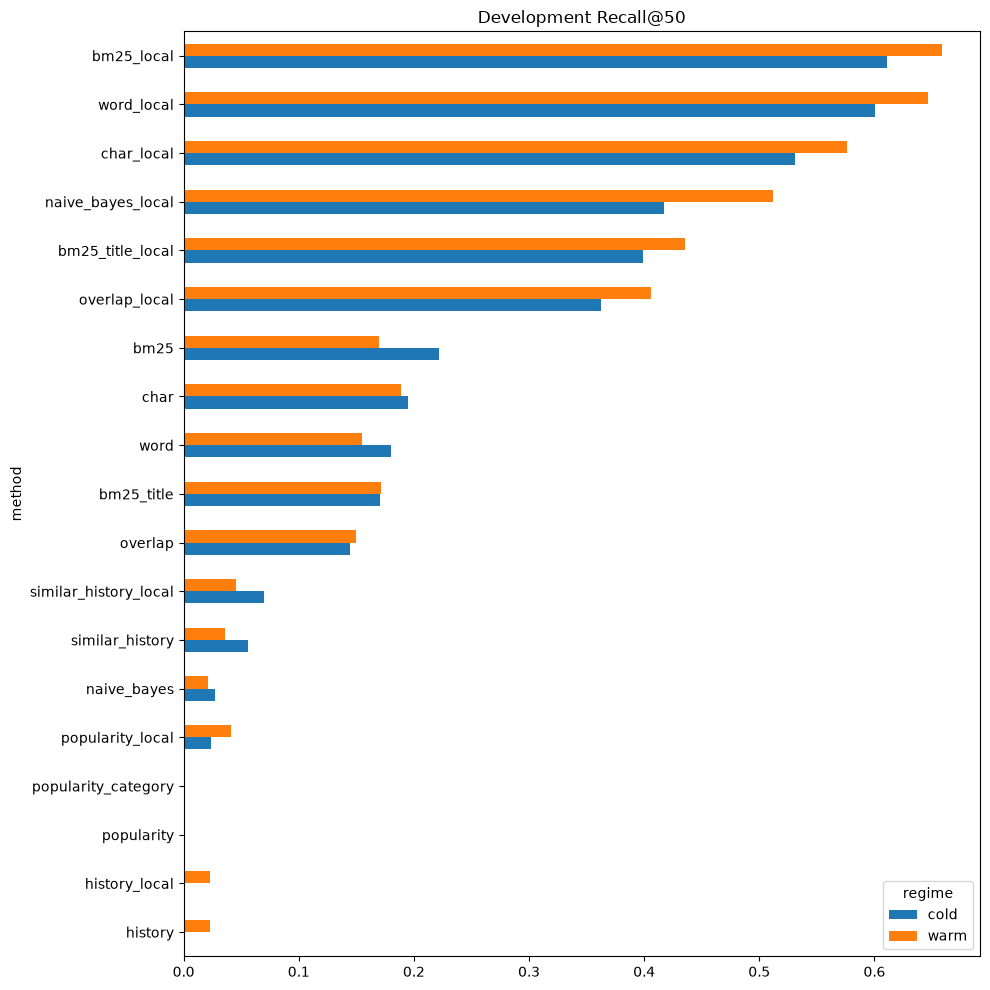

In [6]:
display(bl_scores.sort_values(['regime', 'recall@50'], ascending=[True, False]))
bl_scores.pivot(index='method', columns='regime', values='recall@50').sort_values(
    'cold'
).plot.barh(figsize=(10, 10), title='Development Recall@50')
plt.tight_layout()
plt.savefig(bl_out / 'figures/baselines.png', dpi=150)
plt.show()


## Вывод

На dev лучшие отдельные источники -- локальные BM25 и word TF-IDF. История полного контекста
не находит отложенные контексты по определению split. История текста может использовать другие
фильтры и локации. Пустые ответы оставляю в macro Recall. Следующий шаг -- проверить объединение источников.

In [7]:
bl_best = bl_scores.sort_values('recall@50', ascending=False).groupby('regime').head(1)
display(bl_best)


,method,regime,queries,recall@1,recall@10,recall@20,recall@50,recall@100
3,bm25_local,warm,1000,0.192143,0.489786,0.578690,0.658762,0.694464
2,bm25_local,cold,1000,0.187667,0.453311,0.531197,0.611106,0.655972


### Пустой источник полного контекста

`history_context` возвращает ноль кандидатов во всей локальной проверке: полные контексты целиком отложены. Его Recall@50 равен 0 и на cold, и на warm. В таблице и графике перечислены источники с хотя бы одной непустой выдачей; для каждого из них пустые запросы все равно входят в знаменатель.